# **Rapid Express: Análisis de Perfil, Desempeño y Absentismo Laboral**
**(Basado en el dataset interno de incidencias de Recursos Humanos)**

---
### **Exploratory Data Analysis (EDA)**

**Equipo 28 | Analistas:** Emilio, Nuria (Perfil y Desempeño) y Andrea, Ana (Absentismo y Bienestar)

**Objetivos de este Notebook:**
De acuerdo con las instrucciones del proyecto y la estructura de nuestro tablero Kanban, en esta fase trabajaremos exclusivamente con los datos en su formato original (Raw Data). El objetivo es:
1. **Generar resúmenes estadísticos** de las variables nativamente numéricas.
2. **Crear visualizaciones iniciales** para identificar tendencias, distribuciones y anomalías (outliers) en el absentismo.
3. **Detectar correlaciones** entre las variables operativas y sociodemográficas disponibles.

*Nota técnica:* Las transformaciones de tipos de datos (como la conversión de variables categóricas o formatos de texto a numéricos) se han delegado al ticket posterior de **Data Cleaning**.

### Importación de bibliotecas

In [1]:
# Importación de bibliotecas clave para manipulación de datos y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings

# Configuración estética para gráficos de nivel profesional
sns.set_theme(style="whitegrid", palette="muted")
warnings.filterwarnings('ignore') # Ocultar advertencias menores para un notebook más limpio

print("Librerías importadas correctamente. Entorno listo.")

Librerías importadas correctamente. Entorno listo.


### Conexión a Base de Datos y Extracción Inicial
Para asegurar que nuestro análisis sea escalable y consuma siempre los datos más actualizados, hemos automatizado la ingesta conectando el entorno directamente al servidor **MySQL** de la compañía en lugar de usar extracciones manuales en CSV.

In [4]:
# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")
warnings.filterwarnings('ignore')

# 1. PARÁMETROS DE CONEXIÓN 
USER = 'Equipo28'
PASSWORD = 'E1q2u3i4p5o28'
HOST = '212.227.90.6' 
DATABASE = 'Equip_28'
TABLE = 'RRHH'

try:
    # Crear motor de conexión
    engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}/{DATABASE}")
    
    # Ingesta de datos crudos
    df_RRHH = pd.read_sql(f"SELECT * FROM {TABLE}", engine)
    print("Conexión a MySQL exitosa.")
    print(f"Dataset cargado: {df_RRHH.shape[0]} filas y {df_RRHH.shape[1]} columnas.")
except Exception as e:
    print(f"Error de conexión: {e}")

# Verificación de tipos de datos originales
print("\nEsquema de datos crudos:")
df_RRHH.info()

Conexión a MySQL exitosa.
Dataset cargado: 740 filas y 21 columnas.

Esquema de datos crudos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       740 non-null    int64 
 1   Reason_absence           740 non-null    int64 
 2   Month_absence            740 non-null    int64 
 3   Day_week                 740 non-null    int64 
 4   Seasons                  740 non-null    int64 
 5   Transportation_expense   740 non-null    int64 
 6   Distance_Residence_Work  740 non-null    int64 
 7   Service_time             740 non-null    int64 
 8   Age                      740 non-null    int64 
 9   Work_load_Average_day    740 non-null    object
 10  Hit_target               740 non-null    int64 
 11  Disciplinary_failure     740 non-null    object
 12  Education                740 non-null    object
 13  S

### Resúmenes Estadísticos (Media, Mediana, Desviación)
Calculamos las métricas de tendencia central y dispersión. 

*Nota:* Al ser datos crudos, las variables definidas como `VARCHAR` en MySQL (como `Work_load_Average_day` o `Education`) serán omitidas automáticamente por los cálculos matemáticos hasta su posterior limpieza.

In [5]:
# Estadísticas de variables numéricas nativas
resumen = df_RRHH.describe().round(2)
resumen.loc['mediana'] = df_RRHH.select_dtypes(include=[np.number]).median().round(2)

display(resumen)

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Hit_target,Weight,Height,Body_mass_index,Absenteeism_hours
count,740.00,740.00,740.00,740.00,740.00,740.00,740.00,740.00,740.00,740.00,740.00,740.00,740.00,740.00
mean,18.02,19.22,6.32,3.91,2.54,221.33,29.63,12.55,36.45,94.59,79.04,172.11,26.68,6.92
std,11.02,8.43,3.44,1.42,1.11,66.95,14.84,4.38,6.48,3.78,12.88,6.03,4.29,13.33
min,1.00,0.00,0.00,2.00,1.00,118.00,5.00,1.00,27.00,81.00,56.00,163.00,19.00,0.00
25%,9.00,13.00,3.00,3.00,2.00,179.00,16.00,9.00,31.00,93.00,69.00,169.00,24.00,2.00
50%,18.00,23.00,6.00,4.00,3.00,225.00,26.00,13.00,37.00,95.00,83.00,170.00,25.00,3.00
75%,28.00,26.00,9.00,5.00,4.00,260.00,50.00,16.00,40.00,97.00,89.00,172.00,31.00,8.00
max,36.00,28.00,12.00,6.00,4.00,388.00,52.00,29.00,58.00,100.00,108.00,196.00,38.00,120.00
mediana,18.00,23.00,6.00,4.00,3.00,225.00,26.00,13.00,37.00,95.00,83.00,170.00,25.00,3.00


### Visualizaciones: Histogramas, Boxplots y Dispersión
Buscamos identificar visualmente la distribución del absentismo y la presencia de valores atípicos (outliers) que podrían sesgar futuros modelos.

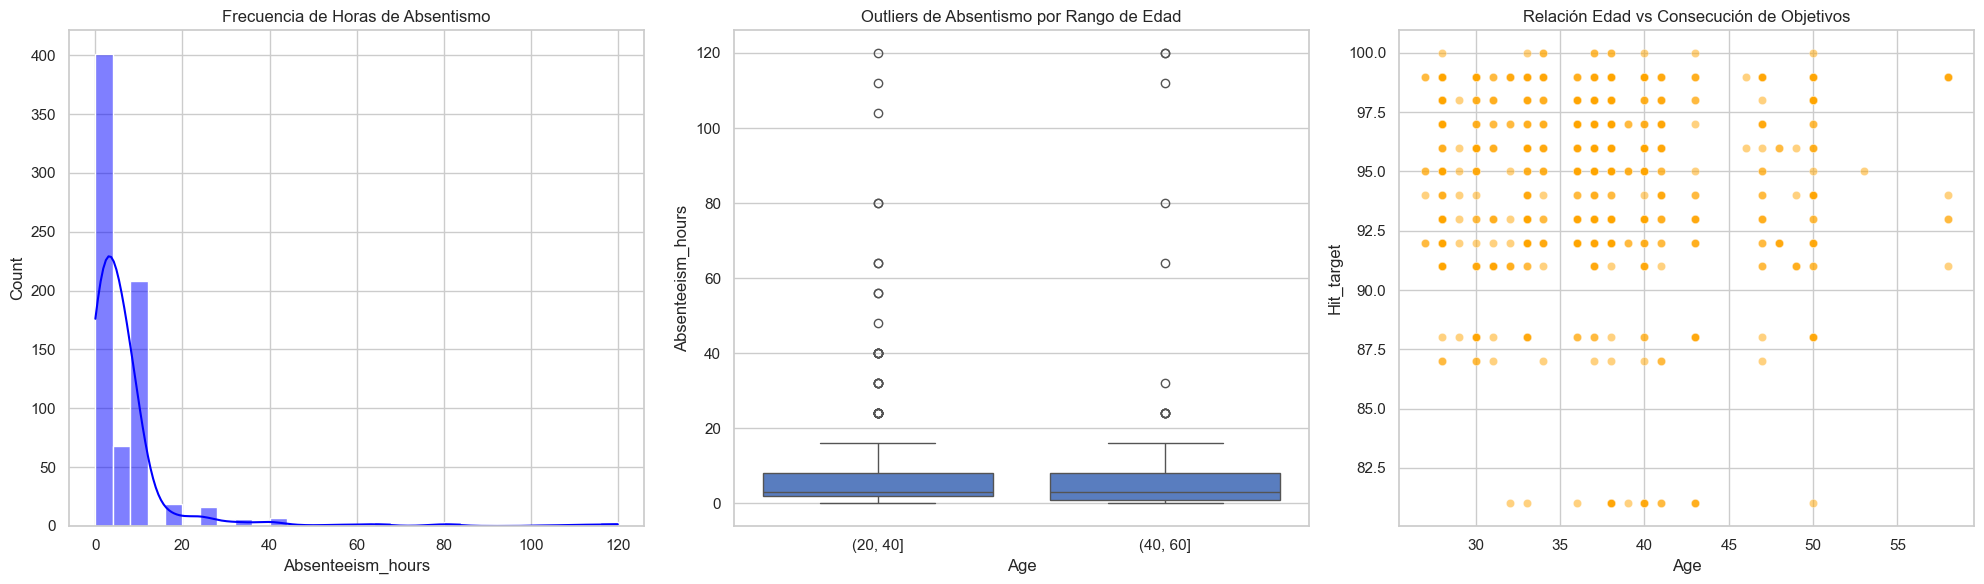

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Histograma: Distribución de Horas de Absentismo
sns.histplot(df_RRHH['Absenteeism_hours'], bins=30, kde=True, color='blue', ax=axes[0])
axes[0].set_title('Frecuencia de Horas de Absentismo')

# Boxplot: Anomalías en Absentismo (Usando variable cruda Age para segmentar)
sns.boxplot(x=pd.cut(df_RRHH['Age'], bins=[20, 40, 60]), y='Absenteeism_hours', data=df_RRHH, ax=axes[1])
axes[1].set_title('Outliers de Absentismo por Rango de Edad')

# Scatter Plot: Edad vs Desempeño (Hit Target)
sns.scatterplot(x='Age', y='Hit_target', data=df_RRHH, alpha=0.5, color='orange', ax=axes[2])
axes[2].set_title('Relación Edad vs Consecución de Objetivos')

plt.tight_layout()
plt.show()

### Matriz de Correlación
Analizamos la fuerza de asociación entre las variables numéricas para identificar qué factores sociodemográficos influyen más en los resultados operativos.

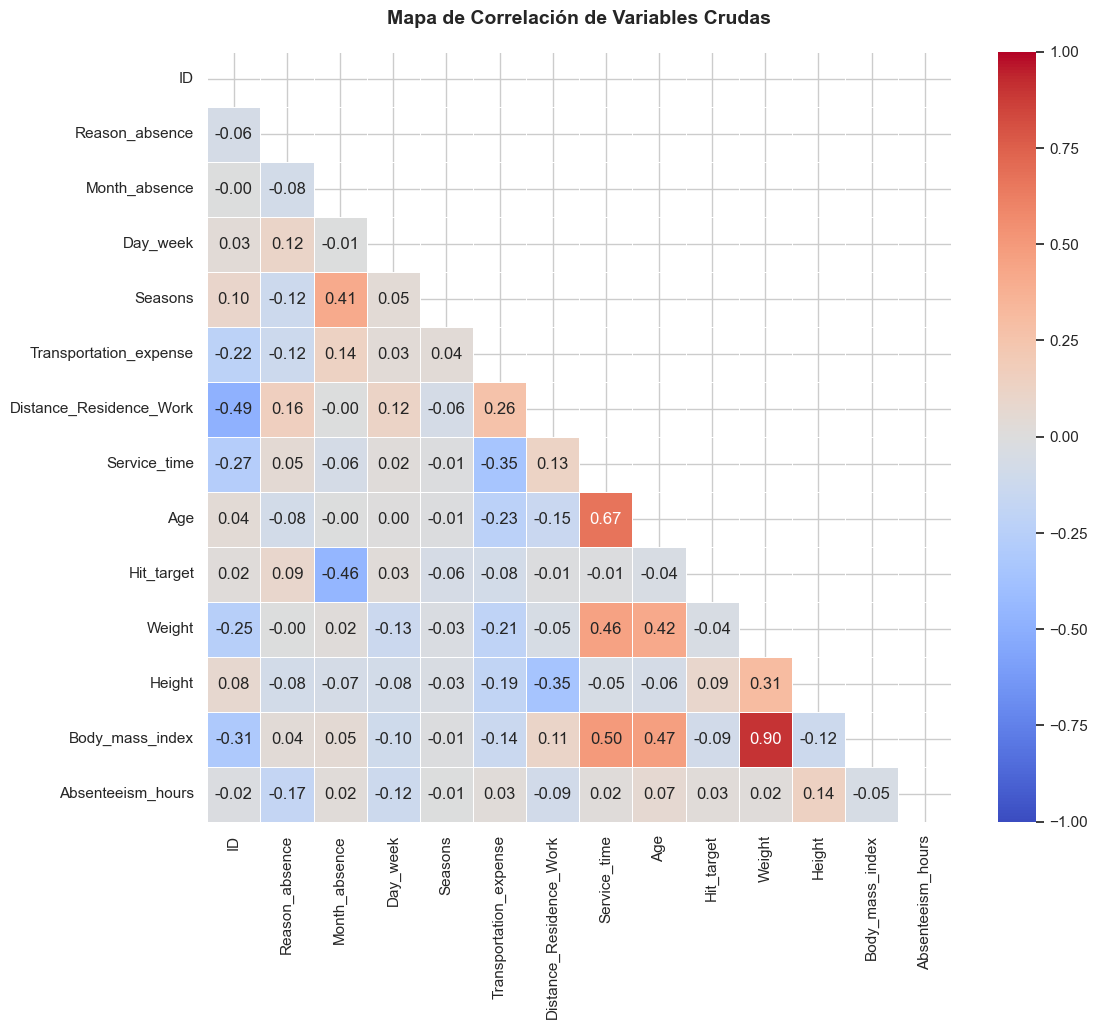

In [ ]:
plt.figure(figsize=(12, 10))

# Correlación de variables numéricas disponibles
corr_matrix = df_RRHH.select_dtypes(include=[np.number]).corr()

# Máscara visual para mayor claridad (oculta el triángulo superior)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Heatmap con la escala de color corregida y centrada en 0
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            cmap='coolwarm', 
            vmin=-1,     # Fuerza el mínimo en -1
            vmax=1,      # Fuerza el máximo en 1
            center=0,    # Fija el color neutro exactamente en el 0
            fmt=".2f", 
            linewidths=0.5)

plt.title('Mapa de Correlación de Variables Crudas', fontsize=14, fontweight='bold', pad=20)
plt.show()

### Conclusiones y Hallazgos del EDA (Datos Crudos)

Basándonos en las visualizaciones y las métricas extraídas en esta primera exploración, destacamos tres conclusiones fundamentales que impactan directamente en el negocio y definen nuestra hoja de ruta técnica:

**1. Bloqueo Técnico en Variables Operativas (Punto Ciego Analítico):**
* **Evidencia:** Al generar la Matriz de Correlación (Heatmap), variables críticas como la Carga de Trabajo (`Work_load_Average_day`), el Nivel Educativo (`Education`) y las Cargas Familiares (`Son`) han sido excluidas automáticamente por el motor de cálculo.
* **Causa:** El esquema de la base de datos de origen almacena estas métricas como cadenas de texto (`VARCHAR`), en gran parte debido al uso de comas decimales.
* **Impacto y Acción:** Actualmente no podemos cruzar matemáticamente el desempeño de un empleado con su volumen de trabajo asignado. Esto justifica de forma irrefutable la necesidad de ejecutar un proceso de *Data Cleaning* y transformación de tipos como paso inmediato antes de modelar los datos.

**2. El Falso Promedio: Absentismo Focalizado vs. Generalizado:**
* **Evidencia:** Tanto el Histograma como los Boxplots muestran una distribución fuertemente sesgada hacia la derecha (*right-skewed*). 
* **Impacto y Acción:** Aunque la inmensa mayoría de las ausencias operativas son de corta duración (1 a 8 horas), existen valores atípicos (*outliers*) extremos que superan las 100 y 120 horas. Esto significa que la "media de horas perdidas" de la empresa está inflada artificialmente por unos pocos casos crónicos. El problema de Rapid Express no es una cultura generalizada de absentismo, sino incidencias médicas o disciplinarias de larga duración muy localizadas que el departamento de Bienestar deberá gestionar caso a caso.

**3. Retención de Talento (El Perfil "Leal"):**
* **Evidencia:** El mapa de correlación de Pearson demuestra una relación positiva fuerte (0.67) entre la Edad del empleado (`Age`) y su Tiempo de Servicio (`Service_time`).
* **Impacto y Acción:** Esto se traduce en una tasa de rotación de personal muy baja. Rapid Express cuenta con una plantilla madura que "hace carrera" dentro de la compañía. Desde la perspectiva de Perfil y Desempeño, esto es una excelente noticia: cualquier inversión económica que hagamos en formación (*Upskilling* para los niveles educativos básicos) tendrá un alto retorno de inversión (ROI), ya que sabemos que el talento no se marchará a la competencia a corto plazo.

---
Próximos pasos (tablero Kanban):
--- 
Solicitamos revisión del equipo (*In Review*) para dar por finalizado este EDA sobre datos crudos y continuar con el ticket de **Data Cleaning**, donde limpiaremos los formatos `VARCHAR` y decidiremos la estrategia de imputación para consolidar el dataset final.